## Fake News Detection PT dataset

Dataset: https://github.com/ro-afonso/fake-news-pt-eu

### Imports

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from urllib.parse import urlparse
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
import tqdm
import re

### Data loading

In [3]:
df = pd.read_csv("../data/dataset.csv")
print(df.head(10))
print(df.describe())

                                                Text           Source  \
0  PJ em operação internacional de tráfico de dro...               DN   
1  O texto foi criado - numa universidade da Repú...              NaN   
2  Nunca pague multas por conduzir sem carta ou s...  Contas Poupança   
3  Depois de António Guterres, uma estátua de D. ...    redes sociais   
4  O MAR, uma droga gratuita que cura pelo menos ...           Coruja   
5  O caos no Serviço Nacional de Saúde Demissão e...              NaN   
6  Concurso para diretor-geral da Saúde será repe...              SOL   
7  PSD quer colocar sistema de saúde português en...               DN   
8  Médicos e farmacêuticos dizem que está a aumen...     SIC Noticias   
9  Avião com 143 pessoas a bordo cai em rio e tod...      Bombeiros24   

                                                 URL  Label  
0  https://www.dn.pt/sociedade/pj-em-operacao-int...      1  
1  https://poligrafo.sapo.pt/fact-check/fact-chec...      1  
2  https:/

Entities (including fact-checking) article count

In [4]:
# --- 1. Extract website/domain from URL ---
df["website"] = df["URL"].apply(lambda x: urlparse(x).netloc.replace("www.", ""))

# --- 2. Count total articles per website ---
total_articles_per_website = df["website"].value_counts()
print("=== Total articles per website ===")
print(total_articles_per_website)
print("\n") 

# --- 3. Count articles per website per label ---
label_counts_per_website = pd.crosstab(df["website"], df["Label"])
print("=== Label counts per website ===")
print(label_counts_per_website)
print("\n")

# --- 4. Check label balance ---
print("=== Label distribution ===")
df["Label"].value_counts(normalize=True)

=== Total articles per website ===
website
sicnoticias.pt         14718
arquivo.pt             13561
poligrafo.sapo.pt       6484
direitapolitica.com     6414
dn.pt                   5369
expresso.pt             4533
magazinelusa.com        3652
jn.pt                   2989
observador.pt           2475
sol.sapo.pt              950
tuga.press               924
semanarioextra.com       710
partilhei.com            238
publico.pt               219
Name: count, dtype: int64


=== Label counts per website ===
Label                    0      1
website                          
arquivo.pt           13561      0
direitapolitica.com   6414      0
dn.pt                    0   5369
expresso.pt              0   4533
jn.pt                    0   2989
magazinelusa.com      3652      0
observador.pt         2385     90
partilhei.com          238      0
poligrafo.sapo.pt     3559   2925
publico.pt              77    142
semanarioextra.com     710      0
sicnoticias.pt           0  14718
sol.sapo.pt   

Label
1    0.50155
0    0.49845
Name: proportion, dtype: float64

Plots from raw data

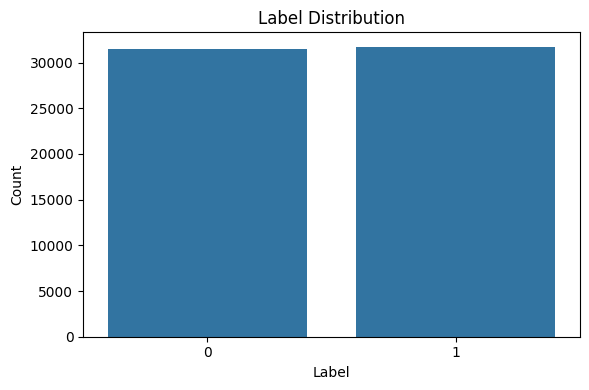

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="Label", data=df)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../plots/label_distribution.png")
plt.show()

In [6]:
df[df["Label"] == 0].sample(10) # shows 10 random samples using label == 0

,Text,Source,URL,Label,website
6507,O arrepiante testemunho de uma mulher que foi ...,Bombeiros24,https://arquivo.pt/wayback/20190905124234mp_/h...,0,arquivo.pt
62179,Nunca pague multas por conduzir sem carta ou s...,Contas Poupança,https://arquivo.pt/wayback/20200626175153mp_/h...,0,arquivo.pt
40650,Negócio com prejuízo de 4 milhões salva candid...,NaN,https://www.direitapolitica.com/negocio-com-pr...,0,direitapolitica.com
37519,Duas mulheres morrem e um bebé fica ferido num...,NaN,https://arquivo.pt/wayback/20180726144243mp_/h...,0,arquivo.pt
56173,"“Não mudei de endereço pessoal, razão pela qua...",José Sócrates à CNN,https://www.publico.pt/2022/05/20/sociedade/no...,0,publico.pt
59455,Mãe de Rui Pedro deixa carta comovente no dia ...,Bombeiros24,https://arquivo.pt/wayback/20200310145632mp_/h...,0,arquivo.pt
4684,Em publicação que se espalhou nas redes sociai...,redes sociais,https://poligrafo.sapo.pt/fact-check/fact-chec...,0,poligrafo.sapo.pt
42402,ÚLTIMA HORA: Apresentadora MOSTRA Mais do Que ...,NaN,http://www.magazinelusa.com/ultima-hora-aprese...,0,magazinelusa.com
60472,Maioria de esquerda que domina a assembleia da...,NaN,https://www.direitapolitica.com/maioria-de-esq...,0,direitapolitica.com
28470,"""Os russos estão a morrer... é o melhor dinhei...","— Utilizador de Facebook, 28 maio 2023",https://observador.pt/factchecks/fact-check-se...,0,observador.pt


In [7]:
df[df["Label"] == 1].sample(10) # shows 10 random samples using label == 1

,Text,Source,URL,Label,website
45534,ONU acusa Rússia de executar 77 civis na Ucrân...,SIC Noticias,https://sicnoticias.pt/especiais/guerra-russia...,1,sicnoticias.pt
29652,"Saramago, vinho e surf: governo promove Portug...",DN,https://www.dn.pt/sociedade/saramago-vinho-e-s...,1,dn.pt
46765,"A pandemia, o confinamento e a alteração de ro...",NaN,https://poligrafo.sapo.pt/fact-check/fact-chec...,1,poligrafo.sapo.pt
44132,Valha-nos Deus!\nO facto é que estou a ser enx...,Expresso,https://expresso.pt/politica/2023-06-01-Valha-...,1,expresso.pt
61495,Quantos autocarros estão na foto da Câmara Mun...,"— Grupo Mobilizar o Seixal - Fazer Melhor, ...",https://observador.pt/factchecks/imagem-mostra...,1,observador.pt
50142,"Exclusivo Vila Franca investe 6,5 milhões para...",DN,https://www.dn.pt/local/vila-franca-investe-65...,1,dn.pt
53541,Ministro da Administração Interna foi ouvido n...,NaN,https://poligrafo.sapo.pt/fact-check/fact-chec...,1,poligrafo.sapo.pt
32409,Crescimento económico da Guiné-Bissau regressa...,Expresso,https://expresso.pt/internacional/palop/2023-0...,1,expresso.pt
10344,Equipas da região de Lisboa acabaram a época e...,SOL,https://sol.sapo.pt/artigo/800967/equipas-da-r...,1,sol.sapo.pt
16391,Incêndios na Grécia: Governo diz ter realizado...,SIC Noticias,https://sicnoticias.pt/mundo/2023-07-23-Incend...,1,sicnoticias.pt


### Data pre-processing

1. Remove NaN
2. Normalize whitespace
3. Remove duplicates
4. Remove extremely short texts
5. Check outliers
6. Save dataset

In [8]:
# 1. Remove NaN (missing values from rows on the Text feature)
df_clean = df.dropna(subset=["Text"]).reset_index(drop=True)

print(f"Total samples after cleaning: {len(df_clean):,} "
      f"(dropped {len(df) - len(df_clean)} rows with missing Text)")

# 2. Light text normalization
def normalize_text(text):
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    text = text.replace("\n", " ")
    return text

df_clean["Text"] = df_clean["Text"].apply(normalize_text)

# 3. Remove duplicates
df_clean = df_clean.drop_duplicates(subset=["Text"])

# 4. Text length analysis
df_clean["text_length_chars"] = df_clean["Text"].str.len()
df_clean["text_length_words"] = df_clean["Text"].str.split().apply(len)

# 5. Remove extreme outliers
df_clean = df_clean[df_clean["text_length_words"] > 2]
df_clean = df_clean[df_clean["text_length_words"] < 512]

# 6. Save cleaned dataset
df_clean.to_csv("../data/dataset_preprocessed.csv", index=False)
print("Saved cleaned dataset -> dataset_preprocessed.csv")

Total samples after cleaning: 63,236 (dropped 0 rows with missing Text)
Saved cleaned dataset -> dataset_preprocessed.csv


Plotting pre-processed data.

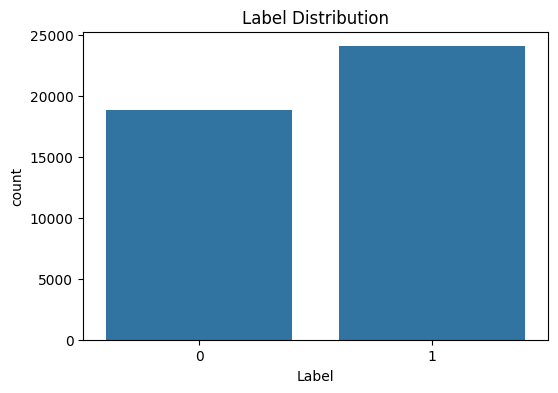

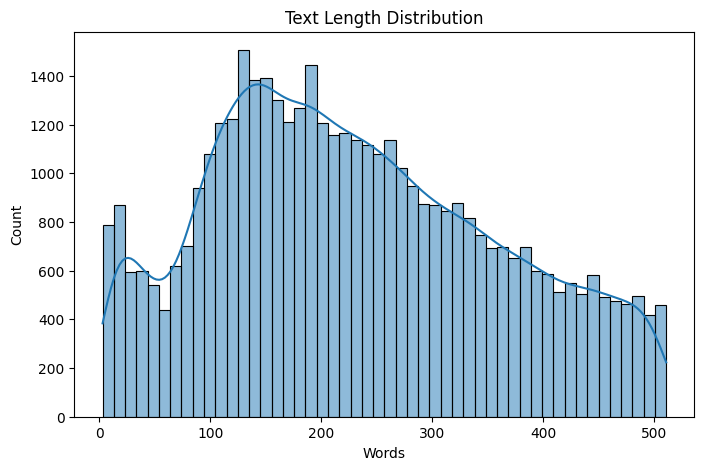

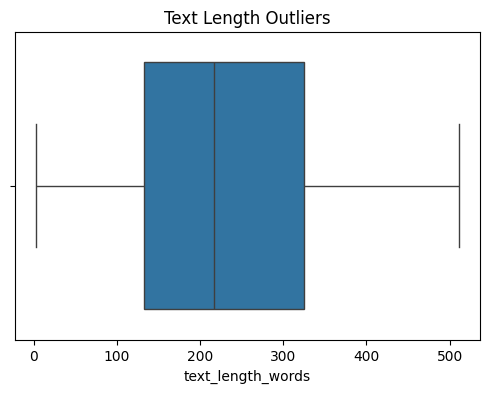

In [9]:
# Label distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Label", data=df_clean)
plt.title("Label Distribution")
plt.savefig("../plots/label_distribution.png")
plt.show()

# Text length histogram
plt.figure(figsize=(8,5))
sns.histplot(df_clean["text_length_words"], bins=50, kde=True)
plt.title("Text Length Distribution")
plt.xlabel("Words")
plt.savefig("../plots/text_length_distribution.png")
plt.show()

# Outlier boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean["text_length_words"])
plt.title("Text Length Outliers")
plt.savefig("../plots/text_length_outliers.png")
plt.show()

### Shuffle and Split data

Training/validation/testing = 80%/10%/10%

In [21]:
# Shuffle dataframe
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Train / Val / Test split (stratified)
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.2,
    stratify=df_clean["Label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["Label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# 3. Save shuffled splits as CSV
train_df.to_csv("../data/train_sample.csv", index=False)
val_df.to_csv("../data/validation_sample.csv", index=False)
test_df.to_csv("../data/test_sample.csv", index=False)

print("Saved CSV splits")

Train: 34383
Validation: 4298
Test: 4298
Saved CSV splits
